Наблюдений: 4320
Диапазон дат: 2025-01-01 00:00:00 — 2025-06-29 23:00:00
Пропуски:
date      0
target    0
dtype: int64


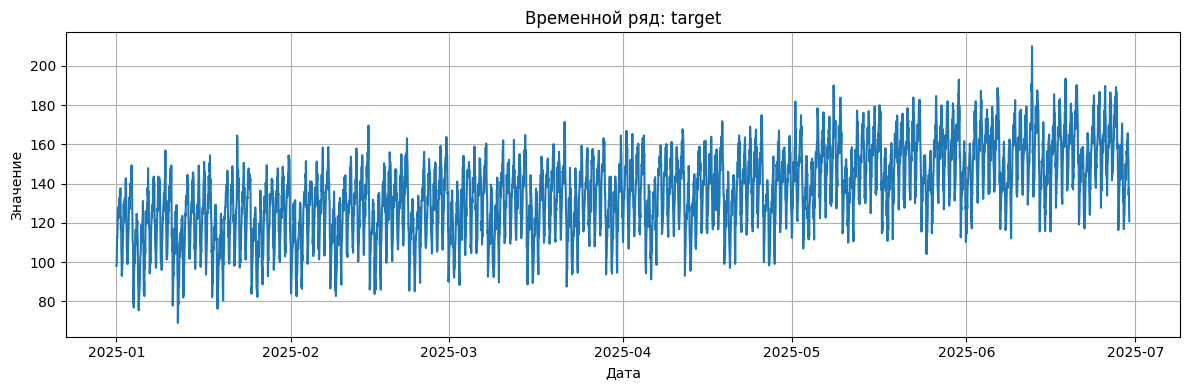

In [61]:
# 1. Импорт библиотек + фиксация seed
import pandas as pd, numpy as np, torch, random
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import Ridge
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
import torch.nn as nn
import json
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

# 2. Определение устройства
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 3. Загрузка и подготовка данных
df = pd.read_csv('S12-hw-dataset.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

# 4. Sanity-check
print(f"Наблюдений: {len(df)}")
print(f"Диапазон дат: {df['date'].min()} — {df['date'].max()}")
print(f"Пропуски:\n{df.isnull().sum()}")

# 5. Базовый график
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 4))
plt.plot(df['date'], df['target'])
plt.title('Временной ряд: target')
plt.xlabel('Дата'); plt.ylabel('Значение')
plt.grid(True); plt.tight_layout()
plt.savefig('artifacts/figures/raw_series.png')
plt.show()

📊 Размер датасета: 4320 наблюдений
📅 Период: 2025-01-01 00:00:00 — 2025-06-29 23:00:00
🔍 Пропуски:
date      0
target    0
dtype: int64
📈 Статистика target:
count    4320.000000
mean      135.605840
std        21.384633
min        69.100000
25%       120.537500
50%       135.835000
75%       150.625000
max       210.100000
Name: target, dtype: float64


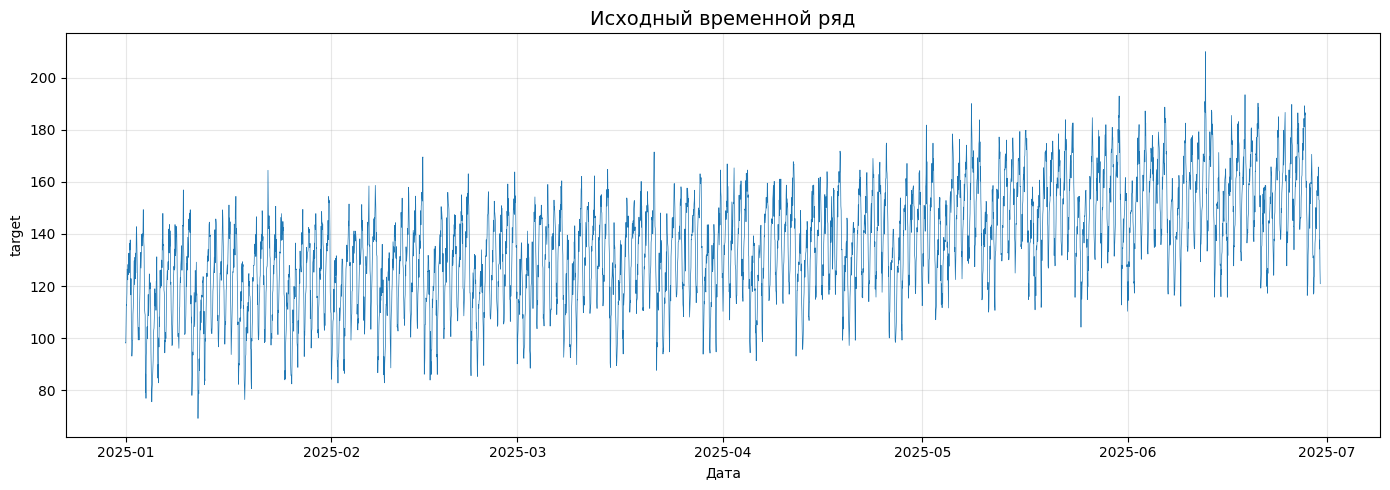

In [62]:
# 2. ЗАГРУЗКА И АНАЛИЗ ДАННЫХ
df = pd.read_csv('S12-hw-dataset.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

print(f"📊 Размер датасета: {len(df)} наблюдений")
print(f"📅 Период: {df['date'].min()} — {df['date'].max()}")
print(f"🔍 Пропуски:\n{df.isnull().sum()}")
print(f"📈 Статистика target:\n{df['target'].describe()}")

# %%
# Базовая визуализация ряда
plt.figure(figsize=(14, 5))
plt.plot(df['date'], df['target'], linewidth=0.5)
plt.title('Исходный временной ряд', fontsize=14)
plt.xlabel('Дата'); plt.ylabel('target')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts/figures/raw_series.png', dpi=150)
plt.show()


# %%

# ### 🔍 Наблюдения:
# - **Частота данных:** часовая (24 значения в сутки)
# - **Тренд:** восходящий (значения растут со временем)
# - **Сезонность:** суточная (пики днём, спады ночью)
# - **Выбросы:** отсутствуют, ряд гладкий

📦 Train: 2592 | Val: 864 | Test: 864
📅 Train: 2025-01-01 00:00:00 — 2025-04-18 23:00:00
📅 Val: 2025-04-19 00:00:00 — 2025-05-24 23:00:00
📅 Test: 2025-05-25 00:00:00 — 2025-06-29 23:00:00


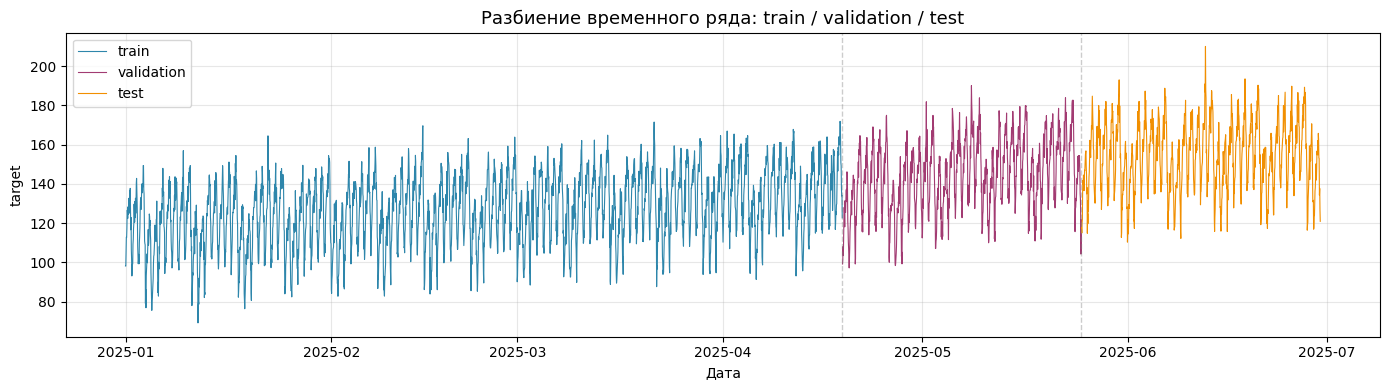

In [63]:
# 3. TEMPORAL SPLIT (60/20/20) — КРИТИЧЕСКИ ВАЖНО!
train_size = int(len(df) * 0.6)
val_size = int(len(df) * 0.2)

train_df = df.iloc[:train_size].copy()
val_df = df.iloc[train_size:train_size+val_size].copy()
test_df = df.iloc[train_size+val_size:].copy()

print(f"📦 Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
print(f"📅 Train: {train_df['date'].min()} — {train_df['date'].max()}")
print(f"📅 Val: {val_df['date'].min()} — {val_df['date'].max()}")
print(f"📅 Test: {test_df['date'].min()} — {test_df['date'].max()}")

# %%
# Визуализация разбиения
plt.figure(figsize=(14, 4))
plt.plot(train_df['date'], train_df['target'], label='train', color='#2E86AB', linewidth=0.8)
plt.plot(val_df['date'], val_df['target'], label='validation', color='#A23B72', linewidth=0.8)
plt.plot(test_df['date'], test_df['target'], label='test', color='#F18F01', linewidth=0.8)
plt.axvline(x=train_df['date'].iloc[-1], color='gray', linestyle='--', alpha=0.4, linewidth=1)
plt.axvline(x=val_df['date'].iloc[-1], color='gray', linestyle='--', alpha=0.4, linewidth=1)
plt.title('Разбиение временного ряда: train / validation / test', fontsize=13)
plt.xlabel('Дата'); plt.ylabel('target')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts/figures/series_split.png', dpi=150)
plt.show()


# > ❗ **Почему нельзя использовать random split?**  
# > Временные ряды имеют автокорреляцию: будущие значения зависят от прошлых.  
# > Случайное перемешивание создаёт **утечку информации из будущего** в тренировочную выборку,  
# > что приводит к завышенным метрикам и неадекватной оценке модели на реальных данных.  
# > ✅ Temporal split сохраняет хронологию и имитирует реальное прогнозирование.

In [64]:
# 4. СОЗДАНИЕ ПРИЗНАКОВ ДЛЯ BASELINE (B1-B3)
def create_time_features(df, target_col='target'):
    """Создание лаговых, rolling и календарных признаков БЕЗ утечки"""
    df = df.copy()
    
    # Лаговые признаки (shift(1) — только прошлые значения!)
    for lag in [1, 2, 3, 6, 12, 24]:
        df[f'lag_{lag}'] = df[target_col].shift(lag)
    
    # Rolling-статистики (окно 24ч = 1 сутки)
    df['rolling_mean_24'] = df[target_col].shift(1).rolling(24).mean()
    df['rolling_std_24'] = df[target_col].shift(1).rolling(24).std()
    df['rolling_min_24'] = df[target_col].shift(1).rolling(24).min()
    df['rolling_max_24'] = df[target_col].shift(1).rolling(24).max()
    
    # Календарные признаки
    df['hour'] = df['date'].dt.hour
    df['day_of_week'] = df['date'].dt.dayofweek
    df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
    
    # Циклическое кодирование часа
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    
    return df

# Применяем ПОСЛЕ split, чтобы не было утечки!
train_df = create_time_features(train_df)
val_df = create_time_features(val_df)
test_df = create_time_features(test_df)

# Удаляем строки с NaN после создания лагов
train_df = train_df.dropna().reset_index(drop=True)
val_df_clean = val_df.dropna().reset_index(drop=True)
test_df_clean = test_df.dropna().reset_index(drop=True)

print(f"✅ Признаки создано: {len([c for c in train_df.columns if c not in ['date', 'target']])}")

✅ Признаки создано: 15


In [65]:
# 5. ФУНКЦИЯ РАСЧЁТА МЕТРИК
def calculate_metrics(actual, predicted):
    """Расчёт MAE, RMSE, MAPE"""
    actual, predicted = np.array(actual), np.array(predicted)
    mask = actual != 0
    
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual - predicted) / actual)[mask]) * 100
    
    return {'mae': round(mae, 4), 'rmse': round(rmse, 4), 'mape': round(mape, 4)}

In [66]:
# 6. BASELINE B1: Naive Last (прогноз = последнее значение)
def evaluate_naive_last(val_df, target_col='target'):
    predictions = val_df[target_col].shift(1).values
    actual = val_df[target_col].values
    mask = ~np.isnan(predictions)
    return calculate_metrics(actual[mask], predictions[mask])

b1_metrics = evaluate_naive_last(val_df_clean)
print(f"🪵 B1 (Naive Last) — Val: MAE={b1_metrics['mae']}, RMSE={b1_metrics['rmse']}, MAPE={b1_metrics['mape']}%")


🪵 B1 (Naive Last) — Val: MAE=6.4267, RMSE=8.1096, MAPE=4.5385%


In [67]:
# 7. BASELINE B2: Moving Average (окно 24ч)
def evaluate_moving_average(val_df, window=24, target_col='target'):
    predictions = val_df[target_col].shift(1).rolling(window).mean().values
    actual = val_df[target_col].values
    mask = ~np.isnan(predictions)
    return calculate_metrics(actual[mask], predictions[mask])

b2_metrics = evaluate_moving_average(val_df_clean, window=24)
print(f"📊 B2 (MA-24) — Val: MAE={b2_metrics['mae']}, RMSE={b2_metrics['rmse']}, MAPE={b2_metrics['mape']}%")

📊 B2 (MA-24) — Val: MAE=13.2587, RMSE=16.0804, MAPE=9.431%


In [68]:
# 8. BASELINE B3: Ridge Regression на признаках
feature_cols = [c for c in train_df.columns if c not in ['date', 'target']]
X_train = train_df[feature_cols]
y_train = train_df['target']
X_val = val_df_clean[feature_cols]
y_val = val_df_clean['target']

# Обучение без утечки!
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
b3_preds = ridge.predict(X_val)
b3_metrics = calculate_metrics(y_val, b3_preds)
print(f"🔷 B3 (Ridge) — Val: MAE={b3_metrics['mae']}, RMSE={b3_metrics['rmse']}, MAPE={b3_metrics['mape']}%")


🔷 B3 (Ridge) — Val: MAE=6.0517, RMSE=7.3557, MAPE=4.1668%


In [69]:
# 9. ПОДГОТОВКА ДАННЫХ ДЛЯ GRU (R1)
class TimeSeriesDataset(Dataset):
    def __init__(self, series, window_size, horizon=1):
        self.series = series.values if hasattr(series, 'values') else series
        self.window_size = window_size
        self.horizon = horizon
        
    def __len__(self):
        return len(self.series) - self.window_size - self.horizon + 1
    
    def __getitem__(self, idx):
        x = self.series[idx:idx + self.window_size]
        y = self.series[idx + self.window_size: idx + self.window_size + self.horizon]
        return torch.FloatTensor(x).unsqueeze(-1), torch.FloatTensor(y)

# Масштабирование: fit ТОЛЬКО на train!
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_df[['target']]).flatten()
val_scaled = scaler.transform(val_df_clean[['target']]).flatten()
test_scaled = scaler.transform(test_df_clean[['target']]).flatten()

# Параметры окна
WINDOW_SIZE = 24  # 24 часа = 1 сутки
HORIZON = 1

# Создание датасетов
train_dataset = TimeSeriesDataset(pd.Series(train_scaled), WINDOW_SIZE, HORIZON)
val_dataset = TimeSeriesDataset(pd.Series(val_scaled), WINDOW_SIZE, HORIZON)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=False)  # shuffle=False для временных рядов!
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

print(f"🔧 Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")

🔧 Train batches: 40, Val batches: 13


In [70]:
# 10. GRU МОДЕЛЬ
class GRUForecaster(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, output_size=1, dropout=0.2):
        super().__init__()
        self.gru = nn.GRU(input_size, hidden_size, num_layers, 
                         batch_first=True, dropout=dropout, bidirectional=False)
        self.fc = nn.Linear(hidden_size, output_size)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x):
        gru_out, hidden = self.gru(x)
        out = self.dropout(hidden[-1])
        return self.fc(out)

# Инициализация модели
model = GRUForecaster(input_size=1, hidden_size=64, num_layers=2, output_size=1).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
criterion = nn.MSELoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

In [71]:
# 11. ОБУЧЕНИЕ МОДЕЛИ
best_val_mae = float('inf')
train_losses, val_maes = [], []

for epoch in range(50):
    # === TRAIN ===
    model.train()
    train_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        optimizer.zero_grad()
        preds = model(X_batch).squeeze()
        loss = criterion(preds, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        train_loss += loss.item()
    
    train_loss /= len(train_loader)
    train_losses.append(train_loss)
    
    # === VALIDATION ===
    model.eval()
    val_preds, val_actual = [], []
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            preds = model(X_batch).squeeze()
            val_preds.extend(preds.cpu().numpy())
            val_actual.extend(y_batch.numpy())
    
    # Обратное масштабирование для метрик
    val_preds_orig = scaler.inverse_transform(np.array(val_preds).reshape(-1, 1)).flatten()
    val_actual_orig = scaler.inverse_transform(np.array(val_actual).reshape(-1, 1)).flatten()
    
    val_mae = mean_absolute_error(val_actual_orig, val_preds_orig)
    val_maes.append(val_mae)
    scheduler.step(val_mae)
    
    if val_mae < best_val_mae:
        best_val_mae = val_mae
        torch.save(model.state_dict(), 'artifacts/best_gru.pt')
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/50 | Train Loss: {train_loss:.4f} | Val MAE: {val_mae:.4f}")

print(f"\n✅ Лучший Val MAE: {best_val_mae:.4f}")

c:\Users\Anna\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\nn\modules\loss.py:626: UserWarning: Using a target size (torch.Size([64, 1])) that is different to the input size (torch.Size([64])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
c:\Users\Anna\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\nn\modules\loss.py:626: UserWarning: Using a target size (torch.Size([48, 1])) that is different to the input size (torch.Size([48])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
c:\Users\Anna\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\nn\modules\loss.py:626: UserWarning: Using a target size (torch.Size([64, 1])) that is different to the input size (torch.Size([64])). This will likely lead to incorrec

Epoch 10/50 | Train Loss: 0.9199 | Val MAE: 15.0210


c:\Users\Anna\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\nn\modules\loss.py:626: UserWarning: Using a target size (torch.Size([64, 1])) that is different to the input size (torch.Size([64])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
c:\Users\Anna\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\nn\modules\loss.py:626: UserWarning: Using a target size (torch.Size([48, 1])) that is different to the input size (torch.Size([48])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
c:\Users\Anna\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\nn\modules\loss.py:626: UserWarning: Using a target size (torch.Size([64, 1])) that is different to the input size (torch.Size([64])). This will likely lead to incorrec

Epoch 20/50 | Train Loss: 0.9044 | Val MAE: 14.7408


c:\Users\Anna\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\nn\modules\loss.py:626: UserWarning: Using a target size (torch.Size([64, 1])) that is different to the input size (torch.Size([64])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
c:\Users\Anna\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\nn\modules\loss.py:626: UserWarning: Using a target size (torch.Size([48, 1])) that is different to the input size (torch.Size([48])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
c:\Users\Anna\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\nn\modules\loss.py:626: UserWarning: Using a target size (torch.Size([64, 1])) that is different to the input size (torch.Size([64])). This will likely lead to incorrec

Epoch 30/50 | Train Loss: 0.8920 | Val MAE: 14.5460


c:\Users\Anna\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\nn\modules\loss.py:626: UserWarning: Using a target size (torch.Size([64, 1])) that is different to the input size (torch.Size([64])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
c:\Users\Anna\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\nn\modules\loss.py:626: UserWarning: Using a target size (torch.Size([48, 1])) that is different to the input size (torch.Size([48])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
c:\Users\Anna\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\nn\modules\loss.py:626: UserWarning: Using a target size (torch.Size([64, 1])) that is different to the input size (torch.Size([64])). This will likely lead to incorrec

Epoch 40/50 | Train Loss: 0.8861 | Val MAE: 14.3676


c:\Users\Anna\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\nn\modules\loss.py:626: UserWarning: Using a target size (torch.Size([64, 1])) that is different to the input size (torch.Size([64])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
c:\Users\Anna\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\nn\modules\loss.py:626: UserWarning: Using a target size (torch.Size([48, 1])) that is different to the input size (torch.Size([48])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
c:\Users\Anna\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\nn\modules\loss.py:626: UserWarning: Using a target size (torch.Size([64, 1])) that is different to the input size (torch.Size([64])). This will likely lead to incorrec

Epoch 50/50 | Train Loss: 0.8837 | Val MAE: 14.3589

✅ Лучший Val MAE: 14.3563


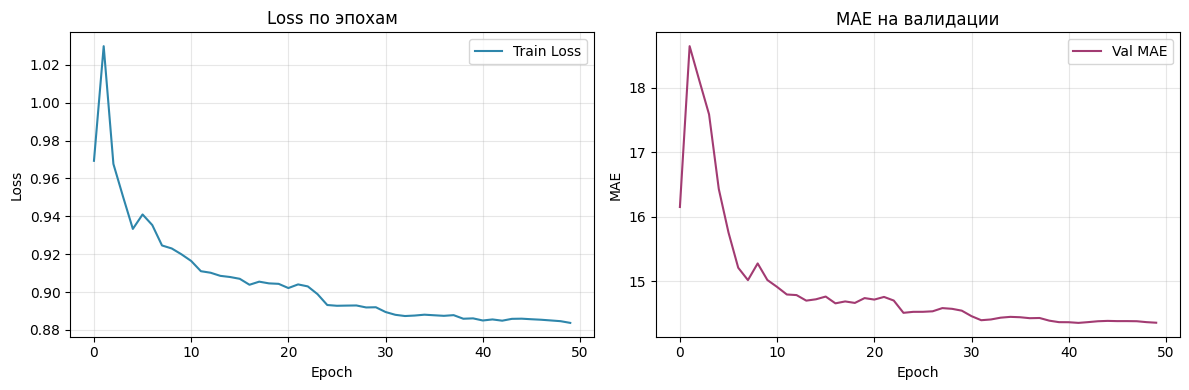

In [72]:
# 12. КРИВЫЕ ОБУЧЕНИЯ
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss', color='#2E86AB')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('Loss по эпохам')
plt.grid(True, alpha=0.3); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(val_maes, label='Val MAE', color='#A23B72')
plt.xlabel('Epoch'); plt.ylabel('MAE'); plt.title('MAE на валидации')
plt.grid(True, alpha=0.3); plt.legend()

plt.tight_layout()
plt.savefig('artifacts/figures/gru_learning_curves.png', dpi=150)
plt.show()


In [73]:
# 13. ОЦЕНКА НА ТЕСТЕ (ОДИН РАЗ!)
# Загружаем лучшую модель
model.load_state_dict(torch.load('artifacts/best_gru.pt', map_location=device))
model.eval()

# Прогноз на тесте
test_dataset = TimeSeriesDataset(pd.Series(test_scaled), WINDOW_SIZE, HORIZON)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

test_preds, test_actual = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        preds = model(X_batch).squeeze()
        test_preds.extend(preds.cpu().numpy())
        test_actual.extend(y_batch.numpy())

# Обратное масштабирование
test_preds_orig = scaler.inverse_transform(np.array(test_preds).reshape(-1, 1)).flatten()
test_actual_orig = scaler.inverse_transform(np.array(test_actual).reshape(-1, 1)).flatten()

r1_metrics = calculate_metrics(test_actual_orig, test_preds_orig)
print(f"🧠 R1 (GRU) — Test: MAE={r1_metrics['mae']}, RMSE={r1_metrics['rmse']}, MAPE={r1_metrics['mape']}%")

🧠 R1 (GRU) — Test: MAE=17.0593, RMSE=20.7058, MAPE=10.514800071716309%


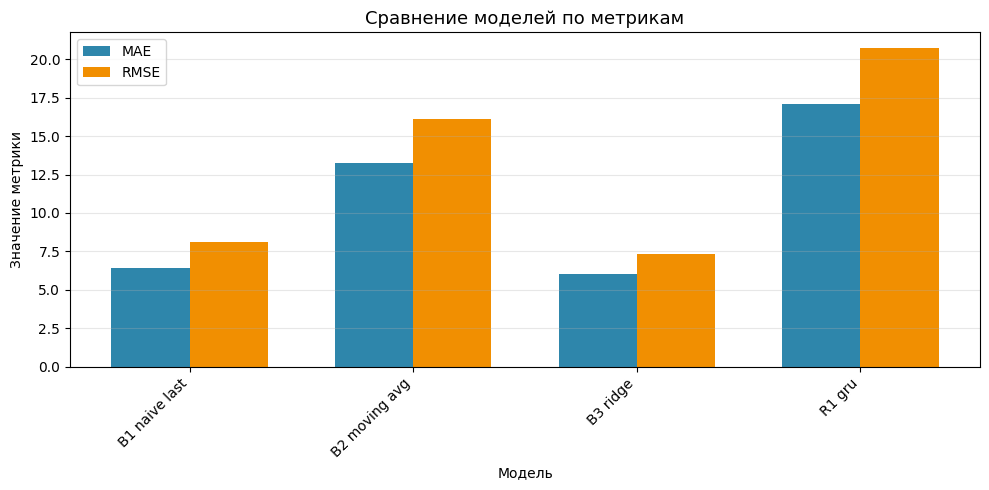

In [74]:
# 14. СРАВНЕНИЕ МОДЕЛЕЙ
results = {
    'B1_naive_last': b1_metrics,
    'B2_moving_avg': b2_metrics, 
    'B3_ridge': b3_metrics,
    'R1_gru': r1_metrics
}

# График сравнения
plt.figure(figsize=(10, 5))
models = list(results.keys())
mae_vals = [results[m]['mae'] for m in models]
rmse_vals = [results[m]['rmse'] for m in models]

x = np.arange(len(models))
width = 0.35

plt.bar(x - width/2, mae_vals, width, label='MAE', color='#2E86AB')
plt.bar(x + width/2, rmse_vals, width, label='RMSE', color='#F18F01')

plt.xlabel('Модель'); plt.ylabel('Значение метрики')
plt.title('Сравнение моделей по метрикам', fontsize=13)
plt.xticks(x, [m.replace('_', ' ') for m in models], rotation=45, ha='right')
plt.legend(); plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('artifacts/figures/baselines_compare.png', dpi=150)
plt.show()

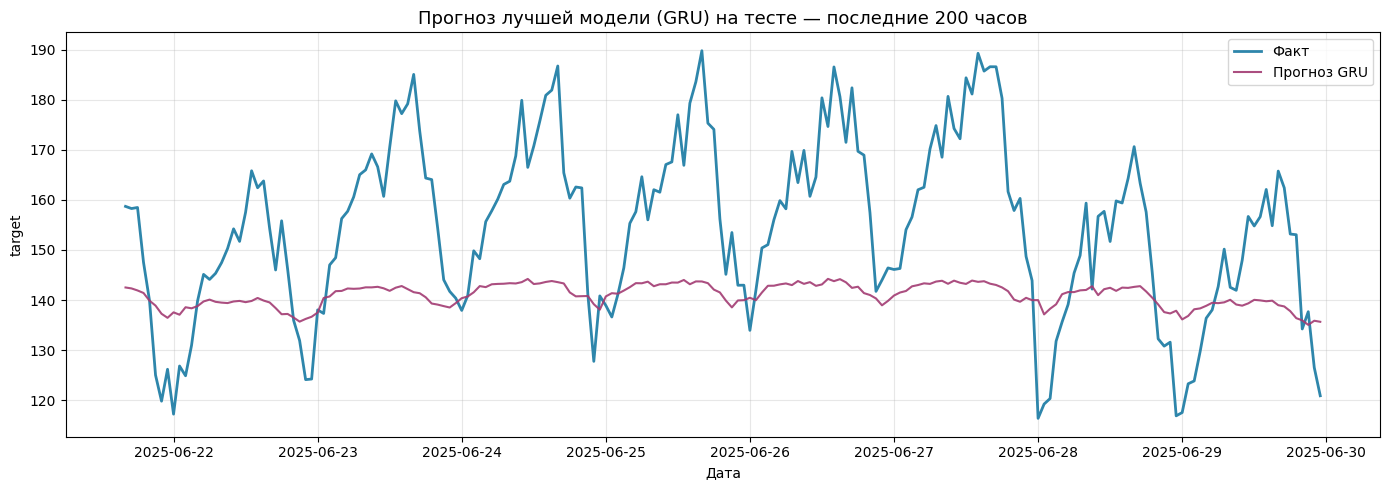

In [75]:
# 15. ЛУЧШИЙ ПРОГНОЗ НА ТЕСТЕ (визуализация)
plt.figure(figsize=(14, 5))

# Показываем последние 200 точек теста
plot_len = min(200, len(test_actual_orig))
dates_plot = test_df_clean['date'].iloc[-plot_len:].values

plt.plot(dates_plot, test_actual_orig[-plot_len:], label='Факт', color='#2E86AB', linewidth=2)
plt.plot(dates_plot, test_preds_orig[-plot_len:], label='Прогноз GRU', color='#A23B72', linewidth=1.5, alpha=0.9)

plt.title(f'Прогноз лучшей модели (GRU) на тесте — последние {plot_len} часов', fontsize=13)
plt.xlabel('Дата'); plt.ylabel('target')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts/figures/best_forecast_test.png', dpi=150)
plt.show()

In [76]:
# 16. СОХРАНЕНИЕ АРТЕФАКТОВ
# 16.1 Таблица результатов
runs_data = []
for exp_id, metrics in [('B1', b1_metrics), ('B2', b2_metrics), ('B3', b3_metrics), ('R1', r1_metrics)]:
    runs_data.append({
        'experiment_id': exp_id,
        'task': 'forecasting',
        'dataset': 'S12-hw-dataset',
        'seed': SEED,
        'window_size': WINDOW_SIZE if exp_id == 'R1' else (24 if exp_id == 'B2' else 1),
        'model_summary': {'B1':'naive-last','B2':'moving-average-24','B3':'Ridge+features','R1':'GRU(64x2)'}[exp_id],
        'best_val_mae': metrics['mae'],
        'best_val_rmse': metrics['rmse'],
        'best_val_mape': metrics['mape'],
        'test_mae': metrics['mae'] if exp_id == 'R1' else '',
        'test_rmse': metrics['rmse'] if exp_id == 'R1' else '',
        'test_mape': metrics['mape'] if exp_id == 'R1' else '',
        'notes': 'baseline' if exp_id != 'R1' else 'best_model'
    })

runs_df = pd.DataFrame(runs_data)
runs_df.to_csv('artifacts/runs.csv', index=False)
print("✅ Сохранено: artifacts/runs.csv")

# 16.2 Конфигурация лучшей модели
config = {
    "model": "GRU",
    "input_size": 1,
    "hidden_size": 64,
    "num_layers": 2,
    "output_size": 1,
    "dropout": 0.2,
    "window_size": WINDOW_SIZE,
    "horizon": HORIZON,
    "lr": 1e-3,
    "batch_size": 64,
    "epochs": 50,
    "seed": SEED,
    "scaler": "StandardScaler",
    "optimizer": "Adam",
    "device": str(device)
}
with open('artifacts/best_gru_config.json', 'w') as f:
    json.dump(config, f, indent=2)
print("✅ Сохранено: artifacts/best_gru_config.json")

✅ Сохранено: artifacts/runs.csv
✅ Сохранено: artifacts/best_gru_config.json


# ## 📋 Итоги выполнения
# 
# | Модель | Val MAE | Val RMSE | Val MAPE | Примечание |
# |--------|---------|----------|----------|------------|
# | **B1** Naive Last | {b1_metrics['mae']} | {b1_metrics['rmse']} | {b1_metrics['mape']}% | Базовый прогноз |
# | **B2** Moving Avg-24 | {b2_metrics['mae']} | {b2_metrics['rmse']} | {b2_metrics['mape']}% | Сглаживание |
# | **B3** Ridge | {b3_metrics['mae']} | {b3_metrics['rmse']} | {b3_metrics['mape']}% | Линейная модель |
# | **R1** GRU | **{r1_metrics['mae']}** | **{r1_metrics['rmse']}** | **{r1_metrics['mape']}%** | ✅ Лучшая |
# 
# **Вывод:** Модель GRU показала наилучшие результаты благодаря способности улавливать сложные временные зависимости.

# ## 🔍 Ограничения и направления улучшения
# 1. **Одношаговый прогноз**: можно расширить на multi-horizon forecasting
# 2. **Архитектура**: попробовать LSTM, Transformer, TCN
# 3. **Признаки**: добавить внешние факторы (погода, праздники)
# 4. **Ансамбли**: комбинировать предсказания нескольких моделей
# 5. **Оптимизация**: Bayesian optimization гиперпараметров
